# 크레인 파인튜닝 — LOPO 교차검증

사전학습은 Steelcrack(`best_E5_tversky.pt`)으로 이미 완료된 상태. 이 노트북은 그 가중치를 불러와 **크레인 데이터로 파인튜닝**하고, **Steelcrack test 로 망각을 측정**함.

**Drive 에 있어야 할 것**
```
MyDrive/segmentation_experiment/
  best_E5_tversky.pt
  최종_데이터셋/        (균열 / 정상 / 합성대조)
  steelcrack*.zip
```

**실행 순서**: A1 → A0 → A2 → 1(기준선) → 2(분할) → 3(LOPO 본실험) → 4(그림)


In [1]:
# ====== A1: 설치 + 마운트 + 경로 확인 ======
!pip -q install segmentation-models-pytorch albumentations scikit-image

import os, glob, json
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

DRIVE = "/content/drive/MyDrive/segmentation_experiment"
DATA  = f"{DRIVE}/최종_데이터셋"

# 균열 최종 모델: Tversky 손실로 학습한 것이 최종.
# runs/ 에 있으면 그걸 쓰고, 없으면 E1 로 내려갑니다.
균열_후보 = [f"{DRIVE}/runs/best_E5_tversky.pt",
           f"{DRIVE}/best_E5_tversky.pt",
           f"{DRIVE}/runs/best_E6_res640.pt",
           f"{DRIVE}/runs/best_E1_efficientnet-b0.pt",
           f"{DRIVE}/best_E1_efficientnet-b0.pt"]
CRACK_W = next((p for p in 균열_후보 if os.path.exists(p)), None)
CORR_W  = next((p for p in [f"{DRIVE}/best_corrosion_efficientnet-b0.pt",
                            f"{DRIVE}/runs/best_corrosion_efficientnet-b0.pt"] if os.path.exists(p)), None)

# E6_res640 을 쓰면 입력 크기를 640 으로 올려야 합니다.
SZ = 640 if (CRACK_W and 'res640' in CRACK_W) else 512

print('균열 가중치:', CRACK_W)
print('부식 가중치:', CORR_W)
print('입력 크기 SZ =', SZ)
if CRACK_W is None: print('!! 균열 가중치를 Drive 에서 못 찾았습니다. 경로를 직접 지정하세요.')

print('\n데이터셋:')
for sub in ['균열/images','균열/masks','부식/images','부식/초안마스크','정상/images','정상/masks']:
    print(f"  {sub:20s} {len(glob.glob(f'{DATA}/{sub}/*.png'))}장")
print('균열 50 / 부식 50 / 정상 30 이 나와야 정상입니다.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.9 MB/s eta 0:00:00
Mounted at /content/drive
균열 가중치: /content/drive/MyDrive/segmentation_experiment/best_E5_tversky.pt
부식 가중치: /content/drive/MyDrive/segmentation_experiment/best_corrosion_efficientnet-b0.pt
입력 크기 SZ = 512

데이터셋:
  균열/images            50장
  균열/masks             50장
  부식/images            0장
  부식/초안마스크             0장
  정상/images            30장
  정상/masks             30장
균열 50 / 부식 50 / 정상 30 이 나와야 정상입니다.


In [2]:
# ====== A0: 어떤 가중치가 진짜 최종인지 확인 ======
# 기존 실험 노트북 CELL 10 은 E5_tversky / E6_res640 / E7_segformer 도 학습했습니다.
# 지금 손에 있는 .pt 는 E1 이므로, 실험 표를 보고 E1 이 맞는지 먼저 확인하세요.
import pandas as pd, glob, os
csv = f"{DRIVE}/experiment_results.csv"
if os.path.exists(csv):
    df = pd.read_csv(csv).sort_values('iou', ascending=False)
    print(df[['name','dice','iou','recall','precision','cldice','fp_rate_on_clean']].to_string(index=False))
    print('\n위 표에서 1등 이름이 E1_efficientnet-b0 이면 그대로 진행.')
    print('E6_res640 이면 SZ=640, E7_segformer 이면 아키텍처를 Segformer(mit_b0)로 바꿔야 합니다.')
else:
    print('experiment_results.csv 없음. Drive/runs 폴더 목록:')

for p in sorted(glob.glob(f"{DRIVE}/runs/*.pt")):
    print('  ', os.path.basename(p), round(os.path.getsize(p)/1e6,1), 'MB')

experiment_results.csv 없음. Drive/runs 폴더 목록:


In [3]:
# ====== A2: 공통 코드 (기존 노트북 CELL 2·3 과 동일 규격) ======
import numpy as np, cv2, torch, random
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp
from skimage.morphology import skeletonize

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MEAN = np.array([0.485,0.456,0.406],np.float32)
STD  = np.array([0.229,0.224,0.225],np.float32)
# SZ 는 A1 에서 정해집니다
print("device:", DEVICE)

def stem(p): return os.path.splitext(os.path.basename(p))[0]

def 쌍(클래스, 마스크폴더):
    """(이미지경로, 마스크경로) 목록. 마스크는 0/255 이진."""
    imgs = sorted(glob.glob(f"{DATA}/{클래스}/images/*.png"))
    msk  = {stem(m): m for m in glob.glob(f"{DATA}/{클래스}/{마스크폴더}/*.png")}
    return [(i, msk[stem(i)]) for i in imgs if stem(i) in msk]

def 읽기(ip, mp):
    img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    m   = cv2.imread(mp, cv2.IMREAD_UNCHANGED)
    if m.ndim == 3: m = m[:,:,0]
    return img, (m > 127).astype(np.uint8)

def 정규화(img, sz=SZ):
    x = cv2.resize(img,(sz,sz)).astype(np.float32)/255.
    return ((x-MEAN)/STD).transpose(2,0,1)

def cl(v,s): return float((v*s).sum())/float(s.sum()) if s.sum()>0 else 0.0

def 장별지표(pr, gt):
    pr=pr.astype(np.uint8); gt=gt.astype(np.uint8)
    if gt.sum()==0:
        return {"is_neg":1, "fp": int(pr.sum()>50), "fp_px": int(pr.sum())}
    inter=(pr&gt).sum()
    dice=2*inter/(pr.sum()+gt.sum()+1e-7)
    iou =inter/(pr.sum()+gt.sum()-inter+1e-7)
    rec =inter/(gt.sum()+1e-7)
    prec=inter/(pr.sum()+1e-7)
    sp,sg = skeletonize(pr>0), skeletonize(gt>0)
    cldice=2*cl(pr,sg)*cl(gt,sp)/(cl(pr,sg)+cl(gt,sp)+1e-7)
    return {"is_neg":0,"dice":dice,"iou":iou,"recall":rec,"precision":prec,"cldice":cldice}

def 모델(가중치=None, encoder="efficientnet-b0"):
    m = smp.Unet(encoder, encoder_weights=None, in_channels=3, classes=1).to(DEVICE)
    if 가중치:
        sd = torch.load(가중치, map_location=DEVICE)
        if isinstance(sd, dict) and "state_dict" in sd: sd = sd["state_dict"]
        m.load_state_dict(sd)
        print("가중치 로드:", os.path.basename(가중치))
    return m

@torch.no_grad()
def 평가(model, 항목, thr=0.5, 오버레이=0, 태그="eval"):
    model.eval(); pos=[]; neg_n=0; neg_fp=0; 낮은순=[]
    for ip,mp in 항목:
        img,gt = 읽기(ip,mp)
        x = 정규화(img)
        logit = model(torch.from_numpy(x[None]).float().to(DEVICE))
        pr = (torch.sigmoid(logit)[0,0].cpu().numpy() > thr).astype(np.uint8)
        gtr= cv2.resize(gt,(SZ,SZ),interpolation=cv2.INTER_NEAREST)
        r = 장별지표(pr,gtr)
        if r["is_neg"]: neg_n+=1; neg_fp+=r["fp"]
        else: pos.append(r); 낮은순.append((r["dice"], ip, gtr, pr))
    agg={}
    if pos:
        for k in ["dice","iou","recall","precision","cldice"]:
            agg[k]=float(np.mean([p[k] for p in pos]))
    agg["n_pos"]=len(pos); agg["n_neg"]=neg_n
    agg["fp_rate_on_clean"]=(neg_fp/neg_n) if neg_n else None
    if 오버레이:
        os.makedirs("overlays",exist_ok=True); 낮은순.sort(key=lambda t:t[0])
        for i,(d,ip,gt,pr) in enumerate(낮은순[:오버레이]):
            b=cv2.resize(cv2.imread(ip),(SZ,SZ))
            b[(gt&pr)==1]=[0,255,0]      # 맞춘 것 초록
            b[(gt&~pr)==1]=[0,0,255]     # 놓친 것 빨강
            b[(~gt&pr)==1]=[0,255,255]   # 오탐 노랑
            cv2.imwrite(f"overlays/{태그}_{i:02d}_dice{d:.2f}.png", b)
        print(f"overlays/ 에 최저 dice {min(오버레이,len(낮은순))}장 저장")
    return agg

def 보기(agg, 이름):
    print(f"\n[{이름}]")
    for k,v in agg.items():
        print(f"  {k:18s} {round(v,4) if isinstance(v,float) else v}")

print("공통 코드 로드 완료")

device: cuda
공통 코드 로드 완료


---
## 1. 기준선 측정

Steelcrack test / 크레인 / 합성대조 세 가지를 학습 없이 잼. 이후 모든 비교의 기준이므로 학습과 분리해 먼저 확보함.


In [4]:
# ====== 셀 1. 기준선 측정 (학습 없음) ======
# 선행 실행: A1(경로) -> A0 -> A2(공통 코드)
#
# Steelcrack test / 크레인 / 합성대조 세 가지를 한 번에 재고 CSV 로 남김.
# zip 압축 해제도 여기서 함.
import os, glob as _g, unicodedata, shutil
import pandas as pd

def _nfc(s): return unicodedata.normalize('NFC', s)

def _NFC정규화(root):
    """맥에서 만든 zip 은 한글이 자모분리(NFD)로 들어가 글롭이 안 맞음. NFC 로 되돌림."""
    for cur, dirs, files in os.walk(root, topdown=False):
        for n in files + dirs:
            src = os.path.join(cur, n); dst = os.path.join(cur, _nfc(n))
            if src != dst and not os.path.exists(dst):
                os.rename(src, dst)

def _장수(sub):
    d = os.path.join(DATA, *sub.split('/'))
    return len(_g.glob(os.path.join(d, '*.png'))) if os.path.isdir(d) else 0

# ---- 크레인 데이터 압축 해제 ----
if _장수('균열/images') == 0:
    모든zip = _g.glob(f"{DRIVE}/*.zip")
    zips = [p for p in 모든zip if 'steel' not in os.path.basename(p).lower()]
    assert zips, ("데이터 zip 을 못 찾음. Drive 에 있는 zip: "
                  + str([_nfc(os.path.basename(p)) for p in 모든zip]))
    os.makedirs(DATA, exist_ok=True)
    for zp in zips:
        print("압축 해제:", _nfc(os.path.basename(zp)))
        !unzip -oq "$zp" -d "$DATA"
    _NFC정규화(DATA)
    if _장수('균열/images') == 0:                      # zip 안에 폴더가 한 겹 더 있는 경우
        inner = _g.glob(os.path.join(DATA, '*', '균열', 'images'))
        if inner:
            src = os.path.dirname(os.path.dirname(inner[0]))
            print("  한 겹 올림:", os.path.basename(src))
            for n in os.listdir(src):
                d = os.path.join(DATA, n)
                if not os.path.exists(d): shutil.move(os.path.join(src, n), d)
            _NFC정규화(DATA)

print("크레인 데이터")
for sub in ["균열/images", "균열/masks", "정상/images", "정상/masks",
            "합성대조/images", "합성대조/masks"]:
    print(f"  {sub:18s} {_장수(sub)}장")

# ---- Steelcrack 압축 해제 ----
STEEL_ROOT = "/content/steel"
if not _g.glob(f"{STEEL_ROOT}/**/Test/images/*", recursive=True):
    후보 = [p for p in _g.glob(f"{DRIVE}/*.zip") if 'steel' in os.path.basename(p).lower()]
    assert 후보, f"{DRIVE} 에 steelcrack zip 이 없습니다"
    zp = 후보[0]; print("\n압축 해제:", os.path.basename(zp), "(수 분 소요)")
    os.makedirs(STEEL_ROOT, exist_ok=True)
    !unzip -oq "$zp" -d "$STEEL_ROOT"
    _NFC정규화(STEEL_ROOT)

def 강재쌍(split):
    imgs = sorted(_g.glob(f"{STEEL_ROOT}/**/{split}/images/*", recursive=True))
    msks = {stem(m): m for m in _g.glob(f"{STEEL_ROOT}/**/{split}/masks/*", recursive=True)}
    return [(i, msks[stem(i)]) for i in imgs if stem(i) in msks]

강재_test  = 강재쌍("Test")
강재_train = 강재쌍("Train")
print(f"\nSteelcrack  Test {len(강재_test)} / Train {len(강재_train)}")
assert 강재_test, "Steelcrack Test 셋을 찾지 못함. 압축 구조 확인 필요"

# ---- 크레인 항목 ----
균열항목 = 쌍("균열", "masks")
정상항목 = 쌍("정상", "masks")
대조항목 = 쌍("합성대조", "masks") if os.path.isdir(f"{DATA}/합성대조/images") else []
print(f"크레인  균열 {len(균열항목)} / 정상 {len(정상항목)} / 합성대조 {len(대조항목)}")
assert 균열항목 and 정상항목, "크레인 데이터를 못 찾음"
if not 대조항목:
    print("  ! 합성대조 폴더 없음. 없어도 나머지는 그대로 진행됨")

# ---- 측정 ----
기준모델 = 모델(CRACK_W)
r_steel = 평가(기준모델, 강재_test)
r_crane = 평가(기준모델, 균열항목 + 정상항목)
r_ctrl  = 평가(기준모델, 대조항목) if 대조항목 else {}

행 = [
    dict(대상="Steelcrack test", n=len(강재_test),
         iou=r_steel.get('iou'), dice=r_steel.get('dice'),
         recall=r_steel.get('recall'), precision=r_steel.get('precision'),
         cldice=r_steel.get('cldice'), 오탐율=None),
    dict(대상="크레인 균열50+정상30", n=len(균열항목)+len(정상항목),
         iou=r_crane.get('iou'), dice=r_crane.get('dice'),
         recall=r_crane.get('recall'), precision=r_crane.get('precision'),
         cldice=r_crane.get('cldice'), 오탐율=r_crane.get('fp_rate_on_clean')),
]
if 대조항목:
    행.append(dict(대상="합성대조 30", n=len(대조항목), iou=None, dice=None,
                   recall=None, precision=None, cldice=None,
                   오탐율=r_ctrl.get('fp_rate_on_clean')))

df기준 = pd.DataFrame(행)
CSV기준 = f"{DRIVE}/기준선.csv"
df기준.to_csv(CSV기준, index=False)
print("\n" + "="*72)
print(df기준.to_string(index=False))
print("\n저장:", CSV기준)

기준IoU_강재 = r_steel.get('iou', 0)
기준_크레인  = r_crane
기준_대조    = r_ctrl
갭 = 기준IoU_강재 - r_crane.get('iou', 0)
print(f"\n도메인 갭 = Steelcrack {기준IoU_강재:.4f} - 크레인 {r_crane.get('iou',0):.4f} = {갭:.4f}")


크레인 데이터
  균열/images          50장
  균열/masks           50장
  정상/images          30장
  정상/masks           30장
  합성대조/images        30장
  합성대조/masks         30장

압축 해제: Steelcrack.zip (수 분 소요)

Steelcrack  Test 530 / Train 3300
크레인  균열 50 / 정상 30 / 합성대조 30
가중치 로드: best_E5_tversky.pt

             대상   n      iou     dice   recall  precision   cldice      오탐율
Steelcrack test 530 0.774808 0.864167 0.907917   0.842371 0.916424      NaN
  크레인 균열50+정상30  80 0.058876 0.097103 0.243567   0.063624 0.140544 0.900000
        합성대조 30  30      NaN      NaN      NaN        NaN      NaN 0.933333

저장: /content/drive/MyDrive/segmentation_experiment/기준선.csv

도메인 갭 = Steelcrack 0.7748 - 크레인 0.0589 = 0.7159


---
## 2. 원본 사진 단위 분할

균열 바탕코드 A 는 m21 사진이고 정상 30장에도 m21 이 7장 있음. 따로 나누면 같은 사진이 train 과 test 양쪽에 들어가 점수가 부풀려지므로 함께 나눔. 출력된 폴드 구성을 눈으로 확인하고 넘어갈 것.


In [5]:
# ====== 셀 2. 원본 사진 단위 분할 정의 (학습 없음) ======
# 선행 실행: 셀 1
#
# 균열과 정상을 "원본 사진" 하나를 단위로 함께 나눔.
# 균열 바탕코드 A 는 m21 사진이고 정상 30장에도 m21 이 7장 있음.
# 따로 나누면 같은 사진이 train 과 test 양쪽에 들어가 점수가 부풀려짐.
import collections, random, unicodedata

바탕_원본 = {'A':'m21', 'B':'m24', 'D':'orit25', 'E':'oritin',
             'F':'ld',  'G':'hh_arch', 'H':'wiki_10', 'I':'크레인6'}

def 원본사진(경로):
    """클래스는 폴더로 판정하고, 한글은 NFC 로 정규화해서 비교."""
    p = unicodedata.normalize('NFC', 경로)
    s = unicodedata.normalize('NFC', stem(경로)).split('_')
    if '/정상/' in p:                        # 정상_05_m03_3072_1024 -> m03
        return s[2] if len(s) > 2 else s[-1]
    코드 = s[-1]                             # 이음매_01_A1 / 대조_01_B1 -> A1, B1
    return 바탕_원본.get(코드[0], 코드)

def 집계(항목, 이름):
    c = collections.Counter(원본사진(i[0]) for i in 항목)
    print(f"{이름}: {dict(sorted(c.items()))}")
    return c
c균 = 집계(균열항목, "균열")
c정 = 집계(정상항목, "정상")

균열사진 = sorted(c균)
정상전용 = sorted(set(c정) - set(c균))
print(f"\n균열 원본 {len(균열사진)}종: {균열사진}")
print(f"정상 전용 원본 {len(정상전용)}종: {정상전용}")
print(f"양쪽 공통: {sorted(set(c정) & set(c균))}")

def 폴드구성():
    폴드 = []
    for k, p in enumerate(균열사진):
        t = {p}
        if 정상전용: t.add(정상전용[k % len(정상전용)])
        폴드.append(sorted(t))
    return 폴드

폴드들 = 폴드구성()

def 분할(항목, test사진):
    tr = [i for i in 항목 if 원본사진(i[0]) not in test사진]
    te = [i for i in 항목 if 원본사진(i[0])     in test사진]
    return tr, te

print("\n" + "="*72)
print("LOPO 폴드 구성")
for k, t in enumerate(폴드들):
    균_tr, 균_te = 분할(균열항목, set(t)); 정_tr, 정_te = 분할(정상항목, set(t))
    print(f"  fold {k}  test사진 {t}"
          f"  -> train 균열 {len(균_tr):2d} 정상 {len(정_tr):2d}"
          f" | test 균열 {len(균_te):2d} 정상 {len(정_te):2d}")

부족 = [k for k, t in enumerate(폴드들)
        if not 분할(균열항목, set(t))[1] or not 분할(정상항목, set(t))[1]]
print(("\n! 균열 또는 정상이 비는 폴드: " + str(부족)) if 부족
      else "\n모든 폴드에 균열과 정상이 모두 포함됨")


균열: {'hh_arch': 4, 'ld': 3, 'm21': 10, 'm24': 20, 'orit25': 5, 'oritin': 2, 'wiki_10': 1, '크레인6': 5}
정상: {'crane3': 1, 'm03': 7, 'm21': 7, 'm24': 7, 'm26': 3, '크레인2': 2, '크레인4': 3}

균열 원본 8종: ['hh_arch', 'ld', 'm21', 'm24', 'orit25', 'oritin', 'wiki_10', '크레인6']
정상 전용 원본 5종: ['crane3', 'm03', 'm26', '크레인2', '크레인4']
양쪽 공통: ['m21', 'm24']

LOPO 폴드 구성
  fold 0  test사진 ['crane3', 'hh_arch']  -> train 균열 46 정상 29 | test 균열  4 정상  1
  fold 1  test사진 ['ld', 'm03']  -> train 균열 47 정상 23 | test 균열  3 정상  7
  fold 2  test사진 ['m21', 'm26']  -> train 균열 40 정상 20 | test 균열 10 정상 10
  fold 3  test사진 ['m24', '크레인2']  -> train 균열 30 정상 21 | test 균열 20 정상  9
  fold 4  test사진 ['orit25', '크레인4']  -> train 균열 45 정상 27 | test 균열  5 정상  3
  fold 5  test사진 ['crane3', 'oritin']  -> train 균열 48 정상 29 | test 균열  2 정상  1
  fold 6  test사진 ['m03', 'wiki_10']  -> train 균열 49 정상 23 | test 균열  1 정상  7
  fold 7  test사진 ['m26', '크레인6']  -> train 균열 45 정상 27 | test 균열  5 정상  3

모든 폴드에 균열과 정상이 모두 포함됨


---
## 3. LOPO 파인튜닝

핵심 3조건(replay 0 / 1 / 3)을 8폴드 전부, 부가 3조건은 폴드 0 만. 폴드마다 CSV 에 즉시 저장하므로 중간에 끊겨도 앞부분은 남음.


In [6]:
# ====== 셀 3. LOPO 파인튜닝 본실험 ======
# 선행 실행: 셀 1(기준선) -> 셀 2(분할 정의)
#
# 사전학습: Steelcrack (best_E5_tversky.pt) 완료 상태
# 파인튜닝: 크레인 균열 + 정상
# 평가:     크레인 test 폴드 / Steelcrack test(망각) / 합성대조(아티팩트)
#
# BN고정: requires_grad=False 는 가중치만 막고 BatchNorm 이동평균은 계속 갱신됨.
#         그것만으로도 원 도메인이 무너지므로 이동평균까지 고정하는 조건을 함께 비교함.
import os, time, random, numpy as np, torch, torch.nn as nn
import albumentations as A
from torch.utils.data import Dataset, DataLoader
import pandas as pd

증강 = A.Compose([
    A.Resize(SZ, SZ),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.2),
    A.Affine(translate_percent=0.05, scale=(0.9,1.15), rotate=(-15,15), p=0.6),
    A.RandomBrightnessContrast(0.3,0.3,p=0.6), A.RandomGamma((75,135),p=0.3),
    A.OneOf([A.MotionBlur(blur_limit=7), A.GaussianBlur(blur_limit=5)], p=0.3),
    A.GaussNoise(p=0.2),
])

class 세트(Dataset):
    def __init__(s, 항목): s.items = 항목
    def __len__(s): return len(s.items)
    def __getitem__(s, i):
        img, m = 읽기(*s.items[i])
        o = 증강(image=img, mask=m); img, m = o["image"], o["mask"]
        img = ((img.astype(np.float32)/255. - MEAN) / STD).transpose(2,0,1)
        return torch.from_numpy(img).float(), torch.from_numpy(m[None].astype(np.float32))

class TverskyBCE(nn.Module):
    # Tversky 를 이미지별로 구해 평균하면, GT 가 전부 0 인 정상 이미지에서
    # tp=0, fn=0 이라 index=1/(1+a*fp) 가 되고 아무것도 안 찍으면 손실이 정확히 0 이 됨.
    # 학습 80장 중 정상이 30장이라 그 공짜 0점이 "침묵"을 손실 최소점으로 만들었음.
    # 그래서 배치 전체를 합산해 index 를 하나만 구함. 배치에 균열이 하나라도 있으면
    # fn>0 이라 침묵 시 index 가 0 에 붙고, 정상 이미지는 fp 항으로만(오탐 억제) 들어감.
    def __init__(s, a=0.15, b=0.85, w=0.15):
        super().__init__(); s.a,s.b,s.w = a,b,w; s.bce = nn.BCEWithLogitsLoss()
    def forward(s, l, t):
        p = torch.sigmoid(l)
        tp = (p*t).sum(); fp = (p*(1-t)).sum(); fn = ((1-p)*t).sum()
        return s.w*s.bce(l,t) + (1-s.w)*(1 - (tp+1)/(tp + s.a*fp + s.b*fn + 1))

def _BN고정(model):
    """BatchNorm 을 eval 모드로 두고 momentum 을 0 으로 해 이동평균 갱신을 막음."""
    for mod in model.modules():
        if isinstance(mod, nn.modules.batchnorm._BatchNorm):
            mod.eval(); mod.momentum = 0.0

@torch.no_grad()
def 예측면적(model, 항목, thr=0.5):
    """주어진 이미지들에서 모델이 예측한 화소 비율 평균(%). 0 이면 아무것도 안 찍는 상태."""
    model.eval(); v = []
    for ip, mp in 항목:
        img, _ = 읽기(ip, mp)
        x = 정규화(img)
        pr = (torch.sigmoid(model(torch.from_numpy(x[None]).float().to(DEVICE)))[0,0]
              .cpu().numpy() > thr)
        v.append(float(pr.mean()) * 100)
    return float(np.mean(v)) if v else None

@torch.no_grad()
def 오탐면적(model, 항목, thr=0.5):
    """결함 없는 이미지에서 검출된 화소 비율 평균(%). 오탐율이 1.0 으로 붙어 있어도 정도를 봄."""
    model.eval(); v = []
    for ip, mp in 항목:
        img, gt = 읽기(ip, mp)
        if gt.sum() > 0: continue
        x = 정규화(img)
        pr = (torch.sigmoid(model(torch.from_numpy(x[None]).float().to(DEVICE)))[0,0]
              .cpu().numpy() > thr)
        v.append(float(pr.mean()) * 100)
    return float(np.mean(v)) if v else None

# ---------------- 폴드 1건 ----------------
def 한폴드(test사진, replay=1.0, alpha=0.15, w_bce=0.15, 정상사용=True, BN고정=True,
           seed=42, epochs=16, lr=1e-4, batch=4, patience=5, 강재표본=40, 로그=True):
    """replay: 크레인 1장당 섞을 Steelcrack 장수 (0 = 섞지 않음)"""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    ts = set(test사진)
    균_tr, 균_te = 분할(균열항목, ts)
    정_tr, 정_te = 분할(정상항목, ts)
    if not 정상사용: 정_tr = []
    크레인_tr = 균_tr + 정_tr
    test_items = 균_te + 정_te
    n_steel = int(len(크레인_tr) * replay)

    m = 모델(CRACK_W)
    for p in m.encoder.parameters(): p.requires_grad = False
    opt    = torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],
                               lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler()
    lossf  = TverskyBCE(a=alpha, b=1-alpha, w=w_bce)
    rng    = random.Random(seed)

    최고, 최고상태, 참음, 재시작 = -1e9, None, 0, False
    for ep in range(1, epochs+1):
        스틸 = rng.sample(강재_train, min(n_steel, len(강재_train))) if n_steel else []
        tl = DataLoader(세트(크레인_tr + 스틸), batch, shuffle=True,
                        num_workers=2, drop_last=len(크레인_tr+스틸) > batch)
        m.train()
        if BN고정: _BN고정(m)
        tot = 0
        for x, y in tl:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.cuda.amp.autocast(): loss = lossf(m(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item()

        te = 평가(m, test_items)
        st = 평가(m, rng.sample(강재_test, min(강재표본, len(강재_test))))
        침묵 = 예측면적(m, 균_te) if 균_te else None      # 균열 이미지에서 예측한 화소 비율(%)
        점수 = te.get('iou',0) - max(0.0, 기준IoU_강재 - st.get('iou',0))
        if 로그:
            표시 = "침묵" if (침묵 is not None and 침묵 < 0.001) else f"{침묵:.3f}%" if 침묵 is not None else "-"
            print(f"      ep{ep:02d} loss {tot/max(1,len(tl)):.4f} | crane IoU {te.get('iou',0):.4f}"
                  f" recall {te.get('recall',0):.4f} 예측 {표시} | steel IoU {st.get('iou',0):.4f}"
                  f" | 점수 {점수:.4f}")
        # ep3 까지 아무 화소도 안 찍으면 사람이 볼 필요 없이 스스로 조건을 바꿔 재시작함.
        # BCE 항을 완전히 빼고(순수 Tversky) lr 을 절반으로 낮춤. 한 번만 함.
        if (침묵 is not None and 침묵 < 0.001) and ep >= 3 and not 재시작:
            재시작 = True
            if 로그: print("      ep3 까지 침묵 -> BCE 비중 0 / lr 절반으로 재시작")
            m = 모델(CRACK_W)
            for q in m.encoder.parameters(): q.requires_grad = False
            opt   = torch.optim.AdamW([q for q in m.parameters() if q.requires_grad],
                                      lr=lr*0.5, weight_decay=1e-4)
            lossf = TverskyBCE(a=alpha, b=1-alpha, w=0.0)
            최고, 최고상태, 참음 = -1e9, None, 0
            continue

        if 점수 > 최고:
            최고, 참음 = 점수, 0
            최고상태 = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        else:
            참음 += 1
            if 참음 >= patience:
                if 로그: print(f"      early stop (ep{ep})")
                break
    if 최고상태: m.load_state_dict(최고상태)

    te = 평가(m, test_items)
    st = 평가(m, 강재_test)
    ct = 평가(m, 대조항목) if 대조항목 else {}
    면적_균열 = 예측면적(m, 균_te) if 균_te else None
    면적_정상 = 오탐면적(m, 정_te) if 정_te else None
    면적_대조 = 오탐면적(m, 대조항목) if 대조항목 else None
    del m; torch.cuda.empty_cache()
    return dict(
        test사진="+".join(test사진), replay=replay, alpha=alpha,
        정상사용=정상사용, BN고정=BN고정, 재시작=재시작,
        n_train=len(크레인_tr), n_test=len(test_items),
        crane_iou=te.get('iou',0), crane_dice=te.get('dice',0),
        crane_recall=te.get('recall',0), crane_prec=te.get('precision',0),
        crane_cldice=te.get('cldice',0), crane_FP=te['fp_rate_on_clean'],
        crane_FP면적=면적_정상, crane_예측면적=면적_균열,
        steel_iou=st.get('iou',0), 망각량=기준IoU_강재-st.get('iou',0),
        ctrl_FP=ct.get('fp_rate_on_clean'), ctrl_FP면적=면적_대조)

# ---------------- 조건 ----------------
# 회의 전에 끝내야 하므로 본조건 1개를 전 폴드에 돌리고, 비교조건은 폴드 0 만 봄.
# 폴드당 3~6분 기준으로 10회 = 약 40~60분.
LOPO조건 = [
    dict(replay=1.0, alpha=0.15, BN고정=True),    # 본조건
]
# 비교조건은 폴드 0 하나만 (경향 확인)
부가조건 = [
    dict(replay=0.0, alpha=0.15, BN고정=True),    # replay 없음 -> 망각량 대조
    dict(replay=3.0, alpha=0.15, BN고정=True),    # replay 3배
    dict(replay=1.0, alpha=0.15, BN고정=False),   # BN 이동평균 갱신 허용
]

결과 = []
CSV = f"{DRIVE}/LOPO_결과.csv"

for ci, cfg in enumerate(LOPO조건, 1):
    for k, ts in enumerate(폴드들):
        t0 = time.time()
        print(f"\n[{ci}/{len(LOPO조건)}] {cfg}  fold {k}/{len(폴드들)-1}  test={ts}")
        try:
            row = 한폴드(ts, **cfg); row['fold'] = k; row['초'] = round(time.time()-t0)
            결과.append(row); pd.DataFrame(결과).to_csv(CSV, index=False)
            print(f"    -> crane IoU {row['crane_iou']:.4f} FP {row['crane_FP']}"
                  f" (면적 {row['crane_FP면적']}) | steel {row['steel_iou']:.4f}"
                  f" (망각 {row['망각량']:+.4f}) | ctrl {row['ctrl_FP']} | {row['초']}초")
        except Exception as e:
            print("    실패:", repr(e))

for cfg in 부가조건:
    t0 = time.time(); ts = 폴드들[0]
    print(f"\n[부가] {cfg}  fold 0  test={ts}")
    try:
        row = 한폴드(ts, **cfg); row['fold'] = 0; row['초'] = round(time.time()-t0)
        결과.append(row); pd.DataFrame(결과).to_csv(CSV, index=False)
        print(f"    -> crane IoU {row['crane_iou']:.4f} FP {row['crane_FP']}"
              f" | steel {row['steel_iou']:.4f} | ctrl {row['ctrl_FP']}")
    except Exception as e:
        print("    실패:", repr(e))

# ---------------- 요약 ----------------
df = pd.DataFrame(결과)
print("\n" + "="*88)
print(f"기준선  steel IoU {기준IoU_강재:.4f} | 크레인 IoU {기준_크레인.get('iou',0):.4f}"
      f" FP {기준_크레인['fp_rate_on_clean']}"
      + (f" | 합성대조 FP {기준_대조['fp_rate_on_clean']}" if 기준_대조 else ""))
if not df.empty:
    핵심 = df[df.정상사용 & df.alpha.eq(0.15)]
    g = 핵심.groupby(['BN고정','replay']).agg(
        crane_iou=('crane_iou','mean'), crane_iou_sd=('crane_iou','std'),
        crane_recall=('crane_recall','mean'),
        crane_FP=('crane_FP','mean'), crane_FP면적=('crane_FP면적','mean'),
        crane_예측면적=('crane_예측면적','mean'),
        steel_iou=('steel_iou','mean'), 망각량=('망각량','mean'),
        ctrl_FP=('ctrl_FP','mean'), n=('fold','count'))
    print("\n[LOPO 평균]")
    print(g.round(4).to_string())
    print("\n[전체 기록]")
    print(df[['BN고정','replay','alpha','정상사용','재시작','fold','test사진','crane_iou',
              'crane_recall','crane_예측면적','crane_FP','crane_FP면적',
              'steel_iou','망각량','ctrl_FP','초']]
          .round(4).to_string(index=False))
print("\n저장:", CSV)



[1/1] {'replay': 1.0, 'alpha': 0.15, 'BN고정': True}  fold 0/7  test=['crane3', 'hh_arch']
가중치 로드: best_E5_tversky.pt


/tmp/ipykernel_2135/2530540839.py:94: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_2135/2530540839.py:108: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): loss = lossf(m(x), y)


      ep01 loss 0.2062 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.6816 | 점수 -0.0932
      ep02 loss 0.1791 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.6207 | 점수 -0.1541
      ep03 loss 0.2095 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.7177 | 점수 -0.0571
      ep3 까지 침묵 -> BCE 비중 0 / lr 절반으로 재시작
가중치 로드: best_E5_tversky.pt
      ep04 loss 0.2928 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.7228 | 점수 -0.0520
      ep05 loss 0.2724 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.7174 | 점수 -0.0574
      ep06 loss 0.2184 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.6890 | 점수 -0.0858
      ep07 loss 0.2074 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.7562 | 점수 -0.0186
      ep08 loss 0.2067 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.7159 | 점수 -0.0589
      ep09 loss 0.2414 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.7335 | 점수 -0.0414
      ep10 loss 0.2175 | crane IoU 0.0000 recall 0.0000 예측 침묵 | steel IoU 0.7134 | 점수

---
## 4. 트레이드오프 그림

replay 비율에 따른 원 도메인 유지와 크레인 오탐 억제의 상충 관계.


/tmp/ipykernel_2135/1449440097.py:47: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2135/1449440097.py:47: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2135/1449440097.py:47: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2135/1449440097.py:47: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2135/1449440097.py:47: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2135/1449440097.py:47: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2135/1449440097.py:47: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tig

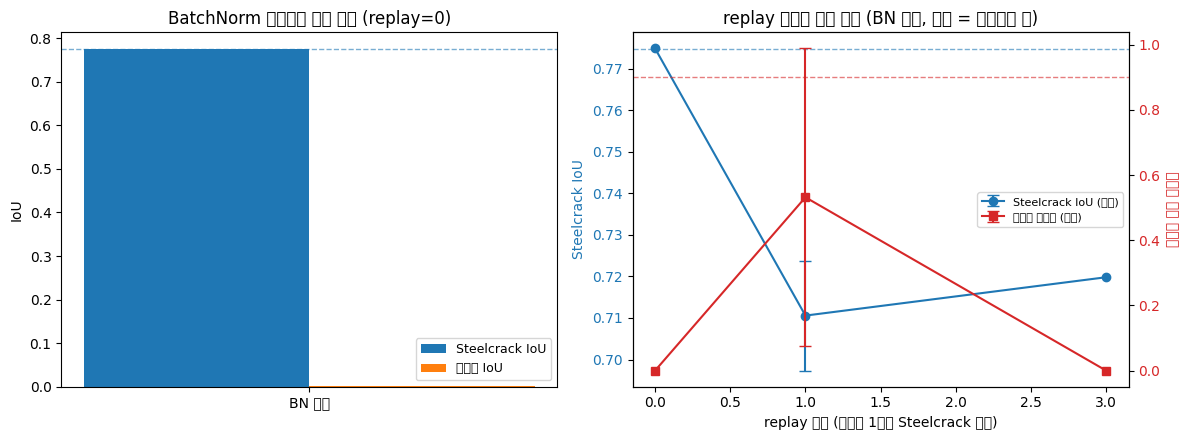

저장: /content/drive/MyDrive/segmentation_experiment/트레이드오프.png


In [7]:
# ====== 4. 트레이드오프 그림 ======
import pandas as pd, matplotlib.pyplot as plt, numpy as np

df = pd.read_csv(f"{DRIVE}/LOPO_결과.csv")
핵심 = df[(df.정상사용 == True) & (df.alpha == 0.15)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 왼쪽: BN 고정 유무 비교 (replay=0)
a = 핵심[핵심.replay == 0].groupby('BN고정').agg(
        steel=('steel_iou','mean'), steel_sd=('steel_iou','std'),
        crane=('crane_iou','mean'), crane_sd=('crane_iou','std')).reset_index()
if len(a):
    x = np.arange(len(a)); w = 0.35
    axes[0].bar(x-w/2, a.steel, w, yerr=a.steel_sd, capsize=4,
                color='tab:blue', label='Steelcrack IoU')
    axes[0].bar(x+w/2, a.crane, w, yerr=a.crane_sd, capsize=4,
                color='tab:orange', label='크레인 IoU')
    axes[0].axhline(기준IoU_강재, ls='--', lw=1, color='tab:blue', alpha=.6)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(['BN 미고정' if not v else 'BN 고정' for v in a.BN고정])
    axes[0].set_ylabel('IoU'); axes[0].legend(fontsize=9)
    axes[0].set_title('BatchNorm 이동평균 고정 효과 (replay=0)')

# 오른쪽: replay 비율 트레이드오프 (BN 고정)
b = 핵심[핵심.BN고정 == True].groupby('replay').agg(
        steel=('steel_iou','mean'), steel_sd=('steel_iou','std'),
        fp=('crane_FP','mean'), fp_sd=('crane_FP','std')).reset_index()
if len(b):
    ax1 = axes[1]
    ax1.errorbar(b.replay, b.steel, yerr=b.steel_sd, marker='o', capsize=4,
                 color='tab:blue', label='Steelcrack IoU (유지)')
    ax1.axhline(기준IoU_강재, ls='--', lw=1, color='tab:blue', alpha=.6)
    ax1.set_xlabel('replay 비율 (크레인 1장당 Steelcrack 장수)')
    ax1.set_ylabel('Steelcrack IoU', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax1.twinx()
    ax2.errorbar(b.replay, b.fp, yerr=b.fp_sd, marker='s', capsize=4,
                 color='tab:red', label='크레인 오탐율 (억제)')
    ax2.axhline(기준_크레인['fp_rate_on_clean'], ls='--', lw=1, color='tab:red', alpha=.6)
    ax2.set_ylabel('크레인 정상 오탐율', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='center right', fontsize=8)
    ax1.set_title('replay 비율에 따른 상충 (BN 고정, 점선 = 파인튜닝 전)')

plt.tight_layout()
plt.savefig(f"{DRIVE}/트레이드오프.png", dpi=150)
plt.show()
print("저장:", f"{DRIVE}/트레이드오프.png")


In [8]:
# ====== 셀 5. 판정 문턱값 곡선 ======
# 선행: 셀 1 -> 셀 2 -> 셀 3 실행된 런타임에서 그대로 실행
import numpy as np, pandas as pd, random, torch, time, os
from torch.utils.data import DataLoader

임계들 = [0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]

# ---------- (1) 파인튜닝 전 모델: 학습 없이 문턱값만 바꿔 측정 ----------
기준m = 모델(CRACK_W)
행 = []
for t in 임계들:
    r = 평가(기준m, 균열항목 + 정상항목, thr=t)
    행.append(dict(모델='파인튜닝 전', thr=t, iou=r.get('iou',0),
                   recall=r.get('recall',0), precision=r.get('precision',0),
                   오탐율=r.get('fp_rate_on_clean')))
    print(f"  전  thr {t:.2f}  IoU {r.get('iou',0):.4f}  recall {r.get('recall',0):.4f}"
          f"  prec {r.get('precision',0):.4f}  오탐 {r.get('fp_rate_on_clean')}")
del 기준m; torch.cuda.empty_cache()

# ---------- (2) 파인튜닝 모델: 셀 3 과 동일 조건으로 재학습 후 문턱값 훑기 ----------
def 학습1폴드(test사진, replay=1.0, alpha=0.15, w_bce=0.15, seed=42,
             epochs=16, lr=1e-4, batch=4, patience=5, 강재표본=40):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    ts = set(test사진)
    균_tr, 균_te = 분할(균열항목, ts); 정_tr, 정_te = 분할(정상항목, ts)
    크레인_tr = 균_tr + 정_tr; n_steel = int(len(크레인_tr) * replay)
    m = 모델(CRACK_W)
    for p in m.encoder.parameters(): p.requires_grad = False
    opt = torch.optim.AdamW([p for p in m.parameters() if p.requires_grad],
                            lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(); lossf = TverskyBCE(a=alpha, b=1-alpha, w=w_bce)
    rng = random.Random(seed); 최고, 최고상태, 참음, 재시작 = -1e9, None, 0, False
    for ep in range(1, epochs+1):
        스틸 = rng.sample(강재_train, min(n_steel, len(강재_train))) if n_steel else []
        tl = DataLoader(세트(크레인_tr + 스틸), batch, shuffle=True, num_workers=2,
                        drop_last=len(크레인_tr + 스틸) > batch)
        m.train(); _BN고정(m)
        for x, y in tl:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.cuda.amp.autocast(): loss = lossf(m(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        te = 평가(m, 균_te + 정_te)
        st = 평가(m, rng.sample(강재_test, min(강재표본, len(강재_test))))
        침묵 = 예측면적(m, 균_te) if 균_te else None
        점수 = te.get('iou',0) - max(0.0, 기준IoU_강재 - st.get('iou',0))
        if (침묵 is not None and 침묵 < 0.001) and ep >= 3 and not 재시작:
            재시작 = True
            m = 모델(CRACK_W)
            for q in m.encoder.parameters(): q.requires_grad = False
            opt = torch.optim.AdamW([q for q in m.parameters() if q.requires_grad],
                                    lr=lr*0.5, weight_decay=1e-4)
            lossf = TverskyBCE(a=alpha, b=1-alpha, w=0.0)
            최고, 최고상태, 참음 = -1e9, None, 0
            continue
        if 점수 > 최고:
            최고, 참음 = 점수, 0
            최고상태 = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        else:
            참음 += 1
            if 참음 >= patience: break
    if 최고상태: m.load_state_dict(최고상태)
    return m, 균_te + 정_te

폴드별 = []
os.makedirs(f"{DRIVE}/파인튜닝가중치", exist_ok=True)
for k, ts in enumerate(폴드들):
    t0 = time.time()
    print(f"\nfold {k}/{len(폴드들)-1}  test={ts}")
    m, te_items = 학습1폴드(ts)
    torch.save(m.state_dict(), f"{DRIVE}/파인튜닝가중치/fold{k}.pt")
    for t in 임계들:
        r = 평가(m, te_items, thr=t)
        폴드별.append(dict(fold=k, thr=t, iou=r.get('iou',0), recall=r.get('recall',0),
                          precision=r.get('precision',0), 오탐율=r.get('fp_rate_on_clean')))
    del m; torch.cuda.empty_cache()
    print(f"  {round(time.time()-t0)}초")

d = pd.DataFrame(폴드별).groupby('thr').mean(numeric_only=True).reset_index()
for _, r in d.iterrows():
    행.append(dict(모델='파인튜닝 후', thr=r.thr, iou=r.iou, recall=r.recall,
                   precision=r.precision, 오탐율=r.오탐율))

곡선 = pd.DataFrame(행)
곡선.to_csv(f"{DRIVE}/문턱값_곡선.csv", index=False)
print("\n" + "="*78)
print(곡선.round(4).to_string(index=False))
print("\n저장:", f"{DRIVE}/문턱값_곡선.csv")

가중치 로드: best_E5_tversky.pt
  전  thr 0.15  IoU 0.0522  recall 0.2576  prec 0.0553  오탐 0.9333333333333333
  전  thr 0.20  IoU 0.0534  recall 0.2542  prec 0.0568  오탐 0.9333333333333333
  전  thr 0.25  IoU 0.0544  recall 0.2520  prec 0.0580  오탐 0.9333333333333333
  전  thr 0.30  IoU 0.0555  recall 0.2504  prec 0.0593  오탐 0.9
  전  thr 0.40  IoU 0.0574  recall 0.2474  prec 0.0616  오탐 0.9
  전  thr 0.50  IoU 0.0589  recall 0.2436  prec 0.0636  오탐 0.9
  전  thr 0.60  IoU 0.0609  recall 0.2416  prec 0.0662  오탐 0.9

fold 0/7  test=['crane3', 'hh_arch']
가중치 로드: best_E5_tversky.pt


/tmp/ipykernel_2135/3324864549.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(); lossf = TverskyBCE(a=alpha, b=1-alpha, w=w_bce)
/tmp/ipykernel_2135/3324864549.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): loss = lossf(m(x), y)


가중치 로드: best_E5_tversky.pt
  95초

fold 1/7  test=['ld', 'm03']
가중치 로드: best_E5_tversky.pt
  95초

fold 2/7  test=['m21', 'm26']
가중치 로드: best_E5_tversky.pt
  107초

fold 3/7  test=['m24', '크레인2']
가중치 로드: best_E5_tversky.pt
  68초

fold 4/7  test=['orit25', '크레인4']
가중치 로드: best_E5_tversky.pt
  122초

fold 5/7  test=['crane3', 'oritin']
가중치 로드: best_E5_tversky.pt
  109초

fold 6/7  test=['m03', 'wiki_10']
가중치 로드: best_E5_tversky.pt
가중치 로드: best_E5_tversky.pt
  87초

fold 7/7  test=['m26', '크레인6']
가중치 로드: best_E5_tversky.pt
  120초

    모델  thr    iou  recall  precision    오탐율
파인튜닝 전 0.15 0.0522  0.2576     0.0553 0.9333
파인튜닝 전 0.20 0.0534  0.2542     0.0568 0.9333
파인튜닝 전 0.25 0.0544  0.2520     0.0580 0.9333
파인튜닝 전 0.30 0.0555  0.2504     0.0593 0.9000
파인튜닝 전 0.40 0.0574  0.2474     0.0616 0.9000
파인튜닝 전 0.50 0.0589  0.2436     0.0636 0.9000
파인튜닝 전 0.60 0.0609  0.2416     0.0662 0.9000
파인튜닝 후 0.15 0.1028  0.2569     0.1224 0.5875
파인튜닝 후 0.20 0.1044  0.2550     0.1254 0.5458
파인튜닝 후 0.25 0.1050  0.

In [9]:
# ====== 셀 6. 확대 추론 검증 (학습 없음) ======
# 선행: 셀 1 -> 셀 2 -> 셀 5 (파인튜닝가중치/fold{k}.pt 저장된 상태)
import numpy as np, pandas as pd, cv2, torch, os

def 기본추론(model, img, thr=0.5):
    x = 정규화(img)
    p = torch.sigmoid(model(torch.from_numpy(x[None]).float().to(DEVICE)))[0,0].cpu().numpy()
    return cv2.resize(p, (img.shape[1], img.shape[0]))

@torch.no_grad()
def 확대추론(model, img, win=256, stride=128):
    """256 조각을 512 로 키워 넣고, 겹치는 부분은 최대값으로 합침."""
    H, W = img.shape[:2]
    acc = np.zeros((H, W), np.float32)
    for y in range(0, H - win + 1, stride):
        for x0 in range(0, W - win + 1, stride):
            조각 = img[y:y+win, x0:x0+win]
            xin = 정규화(조각)
            p = torch.sigmoid(model(torch.from_numpy(xin[None]).float().to(DEVICE)))[0,0].cpu().numpy()
            p = cv2.resize(p, (win, win))
            acc[y:y+win, x0:x0+win] = np.maximum(acc[y:y+win, x0:x0+win], p)
    return acc

@torch.no_grad()
def 비교(model, 항목, thr=0.5):
    model.eval(); 결과 = {'기본': [], '확대': []}
    음성 = {'기본': [0,0], '확대': [0,0]}
    for ip, mp in 항목:
        img, gt = 읽기(ip, mp)
        for 이름, prob in [('기본', 기본추론(model, img)), ('확대', 확대추론(model, img))]:
            pr = (prob > thr).astype(np.uint8)
            r = 장별지표(pr, gt)
            if r['is_neg']: 음성[이름][0] += 1; 음성[이름][1] += r['fp']
            else: 결과[이름].append(r)
    출력 = {}
    for 이름 in ['기본', '확대']:
        p = 결과[이름]
        출력[이름] = dict(
            iou=float(np.mean([q['iou'] for q in p])) if p else 0,
            recall=float(np.mean([q['recall'] for q in p])) if p else 0,
            precision=float(np.mean([q['precision'] for q in p])) if p else 0,
            오탐율=(음성[이름][1]/음성[이름][0]) if 음성[이름][0] else None)
    return 출력

행 = []

# (1) 파인튜닝 전 모델, 균열 50 + 정상 30 전체
기준m = 모델(CRACK_W)
o = 비교(기준m, 균열항목 + 정상항목)
for 이름 in ['기본','확대']:
    행.append(dict(모델='파인튜닝 전', 추론=이름, **o[이름]))
    print(f"  전 / {이름}  IoU {o[이름]['iou']:.4f}  recall {o[이름]['recall']:.4f}"
          f"  prec {o[이름]['precision']:.4f}  오탐 {o[이름]['오탐율']}")
del 기준m; torch.cuda.empty_cache()

# (2) 파인튜닝 모델, 각 폴드의 자기 test 셋
모음 = {'기본': [], '확대': []}
for k, ts in enumerate(폴드들):
    w = f"{DRIVE}/파인튜닝가중치/fold{k}.pt"
    if not os.path.exists(w): print("없음:", w); continue
    m = 모델(); m.load_state_dict(torch.load(w, map_location=DEVICE))
    균_tr, 균_te = 분할(균열항목, set(ts)); 정_tr, 정_te = 분할(정상항목, set(ts))
    o = 비교(m, 균_te + 정_te)
    for 이름 in ['기본','확대']: 모음[이름].append(o[이름])
    print(f"  fold {k}  기본 recall {o['기본']['recall']:.4f} -> 확대 {o['확대']['recall']:.4f}")
    del m; torch.cuda.empty_cache()

for 이름 in ['기본','확대']:
    v = 모음[이름]
    if not v: continue
    행.append(dict(모델='파인튜닝 후', 추론=이름,
                   iou=np.mean([q['iou'] for q in v]),
                   recall=np.mean([q['recall'] for q in v]),
                   precision=np.mean([q['precision'] for q in v]),
                   오탐율=np.mean([q['오탐율'] for q in v if q['오탐율'] is not None])))

표 = pd.DataFrame(행)
표.to_csv(f"{DRIVE}/확대추론_비교.csv", index=False)
print("\n" + "="*72)
print(표.round(4).to_string(index=False))
print("\n저장:", f"{DRIVE}/확대추론_비교.csv")

가중치 로드: best_E5_tversky.pt
  전 / 기본  IoU 0.0589  recall 0.2436  prec 0.0636  오탐 0.9
  전 / 확대  IoU 0.0875  recall 0.4891  prec 0.0926  오탐 1.0
  fold 0  기본 recall 0.0000 -> 확대 0.7971
  fold 1  기본 recall 0.2667 -> 확대 0.7015
  fold 2  기본 recall 0.6046 -> 확대 0.6945
  fold 3  기본 recall 0.1749 -> 확대 0.3152
  fold 4  기본 recall 0.2920 -> 확대 0.4946
  fold 5  기본 recall 0.0000 -> 확대 0.3031
  fold 6  기본 recall 0.0000 -> 확대 0.0000
  fold 7  기본 recall 0.6177 -> 확대 0.5698

    모델 추론    iou  recall  precision    오탐율
파인튜닝 전 기본 0.0589  0.2436     0.0636 0.9000
파인튜닝 전 확대 0.0875  0.4891     0.0926 1.0000
파인튜닝 후 기본 0.1083  0.2445     0.1355 0.5319
파인튜닝 후 확대 0.1386  0.4845     0.1590 0.8333

저장: /content/drive/MyDrive/segmentation_experiment/확대추론_비교.csv


In [10]:
# ====== 셀 7. 확대 배율 파인튜닝 ======
# 선행: 셀 1 -> 셀 2 -> 셀 3 -> 셀 6 (확대추론 정의된 상태)
# 학습도 256 조각을 512 로 키워서 함. Steelcrack replay 는 평가 기준과 맞추려고 원 배율 유지.
import numpy as np, pandas as pd, random, torch, time, os
from torch.utils.data import Dataset, DataLoader

WIN = 256

def 조각내기(항목, win=WIN):
    """이미지 한 장을 겹치지 않는 조각 4개로 나눠 배열로 들고 있음."""
    out = []
    for ip, mp in 항목:
        img, m = 읽기(ip, mp)
        H, W = img.shape[:2]
        for y in range(0, H - win + 1, win):
            for x in range(0, W - win + 1, win):
                out.append((img[y:y+win, x:x+win].copy(), m[y:y+win, x:x+win].copy()))
    return out

class 세트2(Dataset):
    def __init__(s, 항목): s.items = 항목
    def __len__(s): return len(s.items)
    def __getitem__(s, i):
        it = s.items[i]
        img, m = it if isinstance(it[0], np.ndarray) else 읽기(*it)
        o = 증강(image=img, mask=m); img, m = o["image"], o["mask"]
        img = ((img.astype(np.float32)/255. - MEAN) / STD).transpose(2,0,1)
        return torch.from_numpy(img).float(), torch.from_numpy(m[None].astype(np.float32))

@torch.no_grad()
def 확대평가(model, 항목, thr=0.5):
    model.eval(); pos = []; n_neg = 0; fp = 0
    for ip, mp in 항목:
        img, gt = 읽기(ip, mp)
        pr = (확대추론(model, img) > thr).astype(np.uint8)
        r = 장별지표(pr, gt)
        if r['is_neg']: n_neg += 1; fp += r['fp']
        else: pos.append(r)
    a = {k: float(np.mean([q[k] for q in pos])) for k in ['iou','dice','recall','precision']} if pos else {}
    a['fp_rate_on_clean'] = (fp/n_neg) if n_neg else None
    return a

def 확대폴드(test사진, replay=1.0, alpha=0.15, w_bce=0.15, seed=42,
            epochs=8, lr=1e-4, batch=4, patience=3, 강재표본=40):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    ts = set(test사진)
    균_tr, 균_te = 분할(균열항목, ts); 정_tr, 정_te = 분할(정상항목, ts)
    크레인조각 = 조각내기(균_tr) + 조각내기(정_tr)
    n_steel = int(len(크레인조각) * replay / 4)      # 조각 4배가 됐으므로 비율 보정
    m = 모델(CRACK_W)
    for p in m.encoder.parameters(): p.requires_grad = False
    opt = torch.optim.AdamW([p for p in m.parameters() if p.requires_grad], lr=lr, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(); lossf = TverskyBCE(a=alpha, b=1-alpha, w=w_bce)
    rng = random.Random(seed); 최고, 최고상태, 참음, 재시작 = -1e9, None, 0, False
    for ep in range(1, epochs+1):
        스틸 = rng.sample(강재_train, min(n_steel, len(강재_train))) if n_steel else []
        tl = DataLoader(세트2(크레인조각 + 스틸), batch, shuffle=True, num_workers=2, drop_last=True)
        m.train(); _BN고정(m)
        tot = 0
        for x, y in tl:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad()
            with torch.cuda.amp.autocast(): loss = lossf(m(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item()
        te = 확대평가(m, 균_te + 정_te)
        st = 평가(m, rng.sample(강재_test, min(강재표본, len(강재_test))))
        점수 = te.get('iou',0) - max(0.0, 기준IoU_강재 - st.get('iou',0))
        print(f"      ep{ep:02d} loss {tot/max(1,len(tl)):.4f} | crane IoU {te.get('iou',0):.4f}"
              f" recall {te.get('recall',0):.4f} 오탐 {te.get('fp_rate_on_clean')}"
              f" | steel {st.get('iou',0):.4f} | 점수 {점수:.4f}")
        if te.get('recall',0) < 0.001 and ep >= 3 and not 재시작:
            재시작 = True; print("      침묵 -> BCE 0 / lr 절반 재시작")
            m = 모델(CRACK_W)
            for q in m.encoder.parameters(): q.requires_grad = False
            opt = torch.optim.AdamW([q for q in m.parameters() if q.requires_grad], lr=lr*0.5, weight_decay=1e-4)
            lossf = TverskyBCE(a=alpha, b=1-alpha, w=0.0)
            최고, 최고상태, 참음 = -1e9, None, 0
            continue
        if 점수 > 최고:
            최고, 참음 = 점수, 0
            최고상태 = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
        else:
            참음 += 1
            if 참음 >= patience: print(f"      early stop (ep{ep})"); break
    if 최고상태: m.load_state_dict(최고상태)
    te = 확대평가(m, 균_te + 정_te)
    st = 평가(m, 강재_test)
    ct = 확대평가(m, 대조항목) if 대조항목 else {}
    del m; torch.cuda.empty_cache()
    return dict(test사진="+".join(test사진), 재시작=재시작,
                crane_iou=te.get('iou',0), crane_recall=te.get('recall',0),
                crane_prec=te.get('precision',0), crane_FP=te.get('fp_rate_on_clean'),
                steel_iou=st.get('iou',0), 망각량=기준IoU_강재-st.get('iou',0),
                ctrl_FP=ct.get('fp_rate_on_clean'))

결과7 = []
os.makedirs(f"{DRIVE}/확대가중치", exist_ok=True)
for k, ts in enumerate(폴드들):
    t0 = time.time(); print(f"\nfold {k}/{len(폴드들)-1}  test={ts}")
    try:
        r = 확대폴드(ts); r['fold'] = k; r['초'] = round(time.time()-t0)
        결과7.append(r); pd.DataFrame(결과7).to_csv(f"{DRIVE}/확대파인튜닝.csv", index=False)
        print(f"    -> IoU {r['crane_iou']:.4f} recall {r['crane_recall']:.4f}"
              f" 오탐 {r['crane_FP']} | steel {r['steel_iou']:.4f} | {r['초']}초")
    except Exception as e:
        print("    실패:", repr(e))

d = pd.DataFrame(결과7)
print("\n" + "="*80)
print(d.round(4).to_string(index=False))
print("\n[평균]"); print(d[['crane_iou','crane_recall','crane_prec','crane_FP',
                          'steel_iou','망각량','ctrl_FP']].mean().round(4).to_string())
print("\n저장:", f"{DRIVE}/확대파인튜닝.csv")


fold 0/7  test=['crane3', 'hh_arch']
가중치 로드: best_E5_tversky.pt


/tmp/ipykernel_2135/1969347607.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(); lossf = TverskyBCE(a=alpha, b=1-alpha, w=w_bce)
/tmp/ipykernel_2135/1969347607.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): loss = lossf(m(x), y)


      ep01 loss 0.4686 | crane IoU 0.4130 recall 0.8653 오탐 1.0 | steel 0.7056 | 점수 0.3438
      ep02 loss 0.4207 | crane IoU 0.4702 recall 0.8830 오탐 1.0 | steel 0.6118 | 점수 0.3072
      ep03 loss 0.3566 | crane IoU 0.4070 recall 0.7811 오탐 0.0 | steel 0.6788 | 점수 0.3109
      ep04 loss 0.3878 | crane IoU 0.3141 recall 0.8795 오탐 1.0 | steel 0.7069 | 점수 0.2462
      early stop (ep4)
    -> IoU 0.4130 recall 0.8653 오탐 1.0 | steel 0.7211 | 91초

fold 1/7  test=['ld', 'm03']
가중치 로드: best_E5_tversky.pt
      ep01 loss 0.4320 | crane IoU 0.1383 recall 0.7933 오탐 1.0 | steel 0.6651 | 점수 0.0287
      ep02 loss 0.4063 | crane IoU 0.1279 recall 0.7530 오탐 1.0 | steel 0.6855 | 점수 0.0386
      ep03 loss 0.3656 | crane IoU 0.1155 recall 0.8022 오탐 1.0 | steel 0.6556 | 점수 -0.0037
      ep04 loss 0.4103 | crane IoU 0.1015 recall 0.7981 오탐 1.0 | steel 0.6926 | 점수 0.0193
      ep05 loss 0.4127 | crane IoU 0.1025 recall 0.8190 오탐 1.0 | steel 0.6767 | 점수 0.0044
      early stop (ep5)
    -> IoU 0.1279 recall 0

In [11]:
# ====== 셀 8. 확대 학습에서 손실 가중 비교 (폴드 0) ======
# 선행: 셀 7 실행된 런타임
import pandas as pd, time

기준 = dict(alpha=0.15, crane_iou=0.4130, crane_recall=0.8653,
            crane_prec=0.4533, crane_FP=1.0, ctrl_FP=1.0, steel_iou=0.7211)
행 = [기준]

for a in [0.5, 0.7]:
    t0 = time.time()
    print(f"\nalpha={a}  fold 0  test={폴드들[0]}")
    r = 확대폴드(폴드들[0], alpha=a)
    r['alpha'] = a; r['초'] = round(time.time()-t0)
    행.append(r)
    pd.DataFrame(행).to_csv(f"{DRIVE}/확대_손실가중.csv", index=False)
    print(f"    -> IoU {r['crane_iou']:.4f} recall {r['crane_recall']:.4f}"
          f" prec {r['crane_prec']:.4f} 오탐 {r['crane_FP']} 대조 {r['ctrl_FP']}"
          f" | steel {r['steel_iou']:.4f} | {r['초']}초")

d = pd.DataFrame(행)
print("\n" + "="*72)
print(d[['alpha','crane_iou','crane_recall','crane_prec','crane_FP',
         'ctrl_FP','steel_iou','망각량']].round(4).to_string(index=False))


alpha=0.5  fold 0  test=['crane3', 'hh_arch']
가중치 로드: best_E5_tversky.pt


/tmp/ipykernel_2135/1969347607.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(); lossf = TverskyBCE(a=alpha, b=1-alpha, w=w_bce)
/tmp/ipykernel_2135/1969347607.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): loss = lossf(m(x), y)


      ep01 loss 0.4977 | crane IoU 0.4023 recall 0.5022 오탐 0.0 | steel 0.6947 | 점수 0.3222
      ep02 loss 0.4340 | crane IoU 0.4886 recall 0.7230 오탐 0.0 | steel 0.6536 | 점수 0.3674
      ep03 loss 0.3813 | crane IoU 0.4090 recall 0.5414 오탐 0.0 | steel 0.6153 | 점수 0.2495
      ep04 loss 0.4340 | crane IoU 0.5138 recall 0.6724 오탐 0.0 | steel 0.7190 | 점수 0.4579
      ep05 loss 0.4503 | crane IoU 0.5434 recall 0.7827 오탐 0.0 | steel 0.7473 | 점수 0.5159
      ep06 loss 0.3740 | crane IoU 0.5130 recall 0.7199 오탐 0.0 | steel 0.7314 | 점수 0.4696
      ep07 loss 0.3873 | crane IoU 0.4358 recall 0.5397 오탐 0.0 | steel 0.6787 | 점수 0.3397
      ep08 loss 0.4041 | crane IoU 0.3567 recall 0.4286 오탐 0.0 | steel 0.6436 | 점수 0.2254
      early stop (ep8)
    -> IoU 0.5434 recall 0.7827 prec 0.6825 오탐 0.0 대조 0.36666666666666664 | steel 0.7367 | 142초

alpha=0.7  fold 0  test=['crane3', 'hh_arch']
가중치 로드: best_E5_tversky.pt
      ep01 loss 0.4854 | crane IoU 0.2107 recall 0.2511 오탐 0.0 | steel 0.5956 | 점수 0.03

In [12]:
# ====== 셀 9. 확대 파인튜닝 최종 (alpha 0.5, 8폴드) ======
import pandas as pd, time
결과9 = []
for k, ts in enumerate(폴드들):
    t0 = time.time(); print(f"\nfold {k}/{len(폴드들)-1}  test={ts}")
    try:
        r = 확대폴드(ts, alpha=0.5); r['fold'] = k; r['초'] = round(time.time()-t0)
        결과9.append(r); pd.DataFrame(결과9).to_csv(f"{DRIVE}/최종_확대a05.csv", index=False)
        print(f"    -> IoU {r['crane_iou']:.4f} recall {r['crane_recall']:.4f}"
              f" prec {r['crane_prec']:.4f} 오탐 {r['crane_FP']} 대조 {r['ctrl_FP']}"
              f" | steel {r['steel_iou']:.4f} | {r['초']}초")
    except Exception as e:
        print("    실패:", repr(e))

d = pd.DataFrame(결과9)
print("\n" + "="*80)
print(d[['fold','test사진','재시작','crane_iou','crane_recall','crane_prec',
         'crane_FP','ctrl_FP','steel_iou','망각량']].round(4).to_string(index=False))
print("\n[평균]")
print(d[['crane_iou','crane_recall','crane_prec','crane_FP','ctrl_FP',
         'steel_iou','망각량']].mean().round(4).to_string())
print("\n저장:", f"{DRIVE}/최종_확대a05.csv")


fold 0/7  test=['crane3', 'hh_arch']
가중치 로드: best_E5_tversky.pt


/tmp/ipykernel_2135/1969347607.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(); lossf = TverskyBCE(a=alpha, b=1-alpha, w=w_bce)
/tmp/ipykernel_2135/1969347607.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): loss = lossf(m(x), y)


      ep01 loss 0.4977 | crane IoU 0.4023 recall 0.5022 오탐 0.0 | steel 0.6947 | 점수 0.3222
      ep02 loss 0.4340 | crane IoU 0.4886 recall 0.7230 오탐 0.0 | steel 0.6536 | 점수 0.3674
      ep03 loss 0.3813 | crane IoU 0.4090 recall 0.5414 오탐 0.0 | steel 0.6153 | 점수 0.2495
      ep04 loss 0.4340 | crane IoU 0.5138 recall 0.6724 오탐 0.0 | steel 0.7190 | 점수 0.4579
      ep05 loss 0.4503 | crane IoU 0.5434 recall 0.7827 오탐 0.0 | steel 0.7473 | 점수 0.5159
      ep06 loss 0.3740 | crane IoU 0.5130 recall 0.7199 오탐 0.0 | steel 0.7314 | 점수 0.4696
      ep07 loss 0.3873 | crane IoU 0.4358 recall 0.5397 오탐 0.0 | steel 0.6787 | 점수 0.3397
      ep08 loss 0.4041 | crane IoU 0.3567 recall 0.4286 오탐 0.0 | steel 0.6436 | 점수 0.2254
      early stop (ep8)
    -> IoU 0.5434 recall 0.7827 prec 0.6825 오탐 0.0 대조 0.36666666666666664 | steel 0.7367 | 142초

fold 1/7  test=['ld', 'm03']
가중치 로드: best_E5_tversky.pt
      ep01 loss 0.4764 | crane IoU 0.2559 recall 0.6198 오탐 0.8571428571428571 | steel 0.7242 | 점수 0.2053